In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata


import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse


import sys
sys.path.append('/home/xwanaf/bio/scGPT-dev-temp/Atlas_integration/Reproducibility/Validation')
from UniGeneX.utils import *


/home/xwanaf/.conda/envs/unigenex_env/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/xwanaf/.conda/envs/unigenex_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# UGE atlas

In [2]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Benchmarking/reproducibility/Training_output'
file_path = Path(base_path)

atlas_adata = atlas_adata_ref = sc.read(file_path / 'atlas_1e3_maskp5_processed.h5ad')
atlas_adata

AnnData object with n_obs × n_vars = 607328 × 1702
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'tmp'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'leiden_2p5_colors', 'neighbors', 'pca', 'tmp_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### Load metadata to add the required columns.

In [4]:
file_path = '/import/home2/xwanaf/Img2Expr/data/Benchmarking/reproducibility/Training_input/'
obs_concat = pd.read_csv(Path(file_path) / 'obs_concat.csv', index_col = 0)


/tmp/ipykernel_420728/3181310661.py:2: DtypeWarning: Columns (13,16,18,25,28,31,32,33,34,35,36,38,39,40,41,42,44,45,46,47,48,49,52,54,56,58,60) have mixed types. Specify dtype option on import or set low_memory=False.
  obs_concat = pd.read_csv(Path(file_path) / 'obs_concat.csv', index_col = 0)


In [5]:
obs_concat.columns

Index(['index', 'suspension_type', 'donor_id', 'is_primary_data',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'development_stage_ontology_term_id', 'disease_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id',
       'organism_ontology_term_id', 'sex_ontology_term_id', '3'_or_5'', 'BMI',
       'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score',
       'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1',
       'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5',
       'cause_of_death', 'core_or_extension', 'dataset', 'fresh_or_frozen',
       'log10_total_counts', 'lung_condition', 'mixed_ancestry',
       'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3',
       'original_ann_level_4', 'original_ann_level_5',
       'original_ann_nonharmonized', 'reannotation_type', 'sample',
       'scanvi_label', 'sequencing_platform', 'smoking_status', 'study',
 

In [7]:
added_col = [
#     'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized',
    'ann_level_3'
]
for col in added_col:
    atlas_adata.obs[col] = obs_concat.loc[atlas_adata.obs.index][col].copy().tolist()

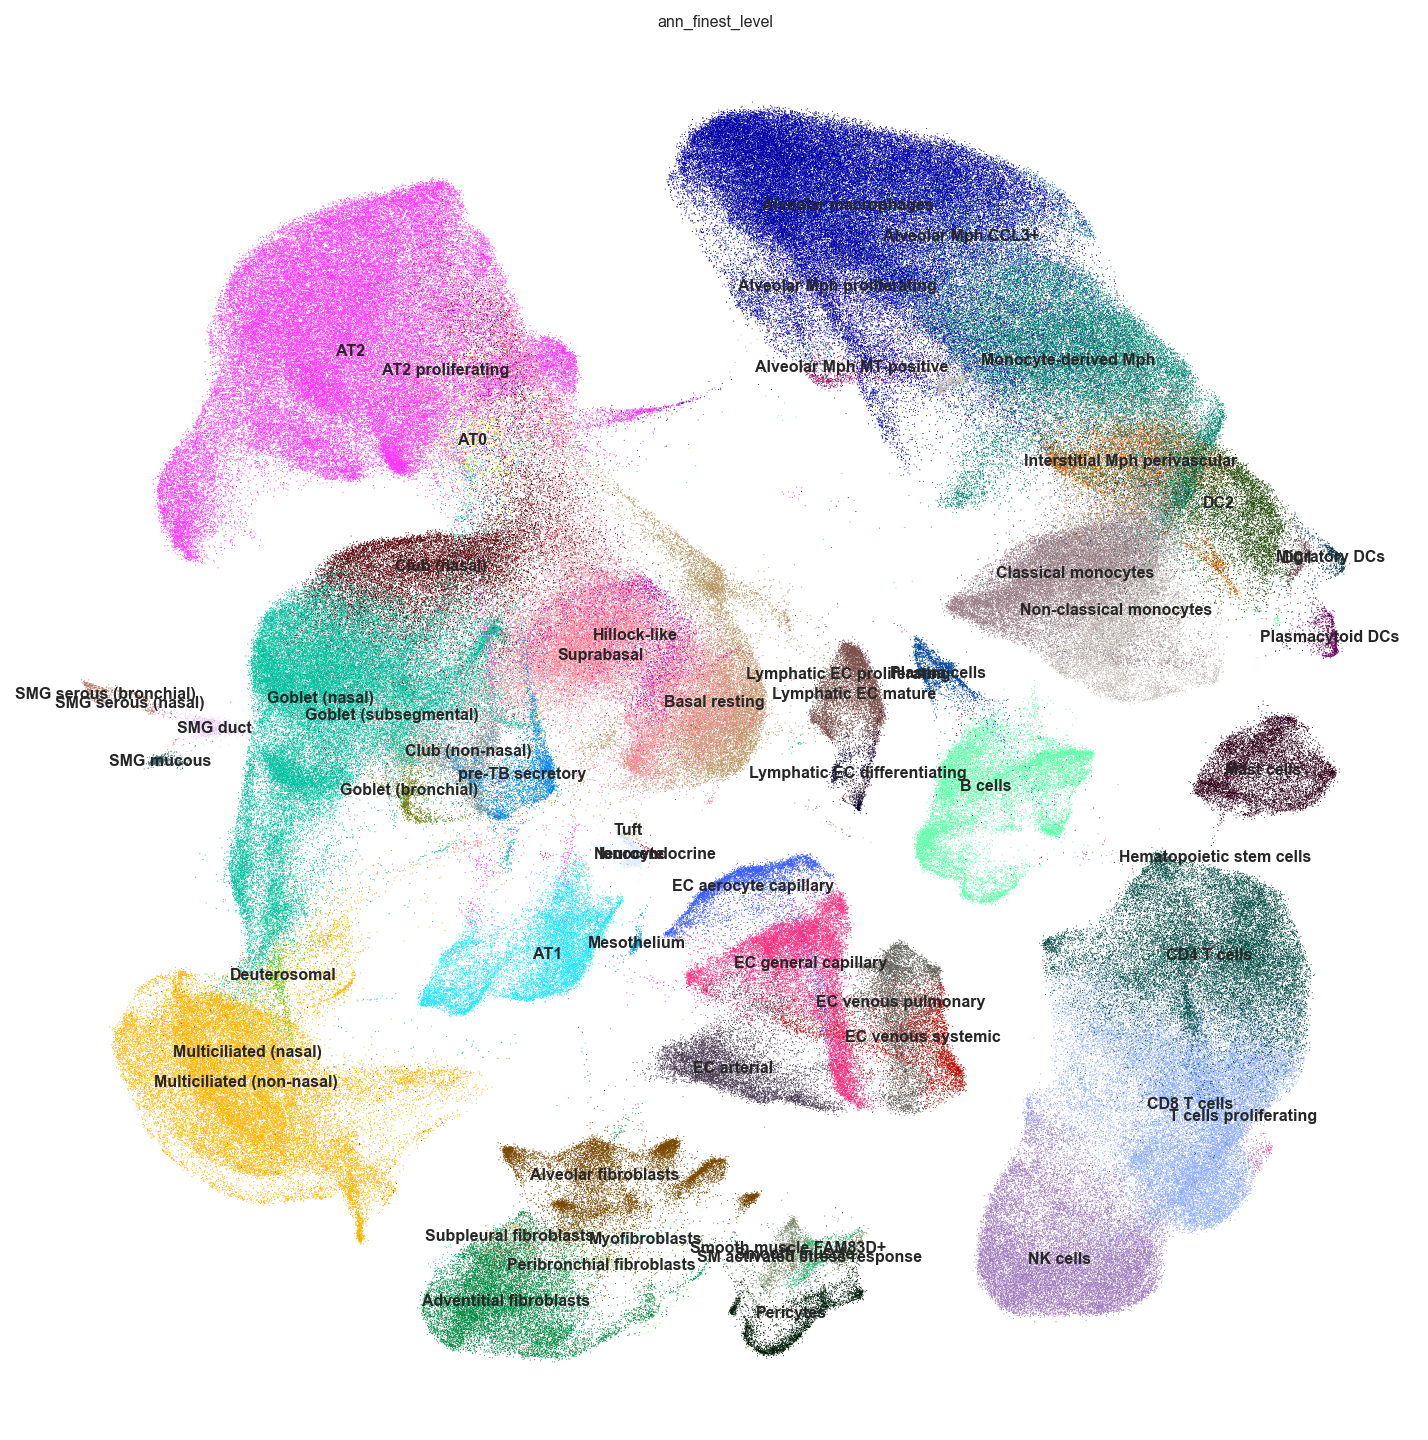

In [9]:
set_vis_default(font = .8, circle_marker = 3.)

# ct_all = adata_all.obs['dataset_names'].astype('category').unique().categories

adata_vis = atlas_adata

fig, axs = plt.subplots(1, 1, figsize=(12, 12), dpi = 150, gridspec_kw={'wspace': .02, 'hspace': 0.05})
# color_dict = get_color_dict(atlas_adata, col = 'ct_v7', uns_key = 'ct_v7_colors')

sc.pl.umap(
    adata_vis, color='ann_finest_level', 
    size=1, frameon=False, show=False, ax=axs, 
#     palette = color_dict, 
#     groups = groups#,
    legend_loc = 'on data' 
)

# plt.savefig(f'./save_figs/atlas_umap.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=1)

plt.show()
plt.close()

## cell type harmonization

In [10]:
atlas_adata

AnnData object with n_obs × n_vars = 607328 × 1702
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'tmp', 'ann_level_3'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'leiden_2p5_colors', 'neighbors', 'pca', 'tmp_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [12]:
assign_ct_col = 'ann_finest_level'
cluster_col = 'leiden_2p5'

/tmp/ipykernel_420728/1199559199.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis = atlas_adata.obs.groupby(cluster_col)[assign_ct_col].value_counts(normalize = True).unstack(0)


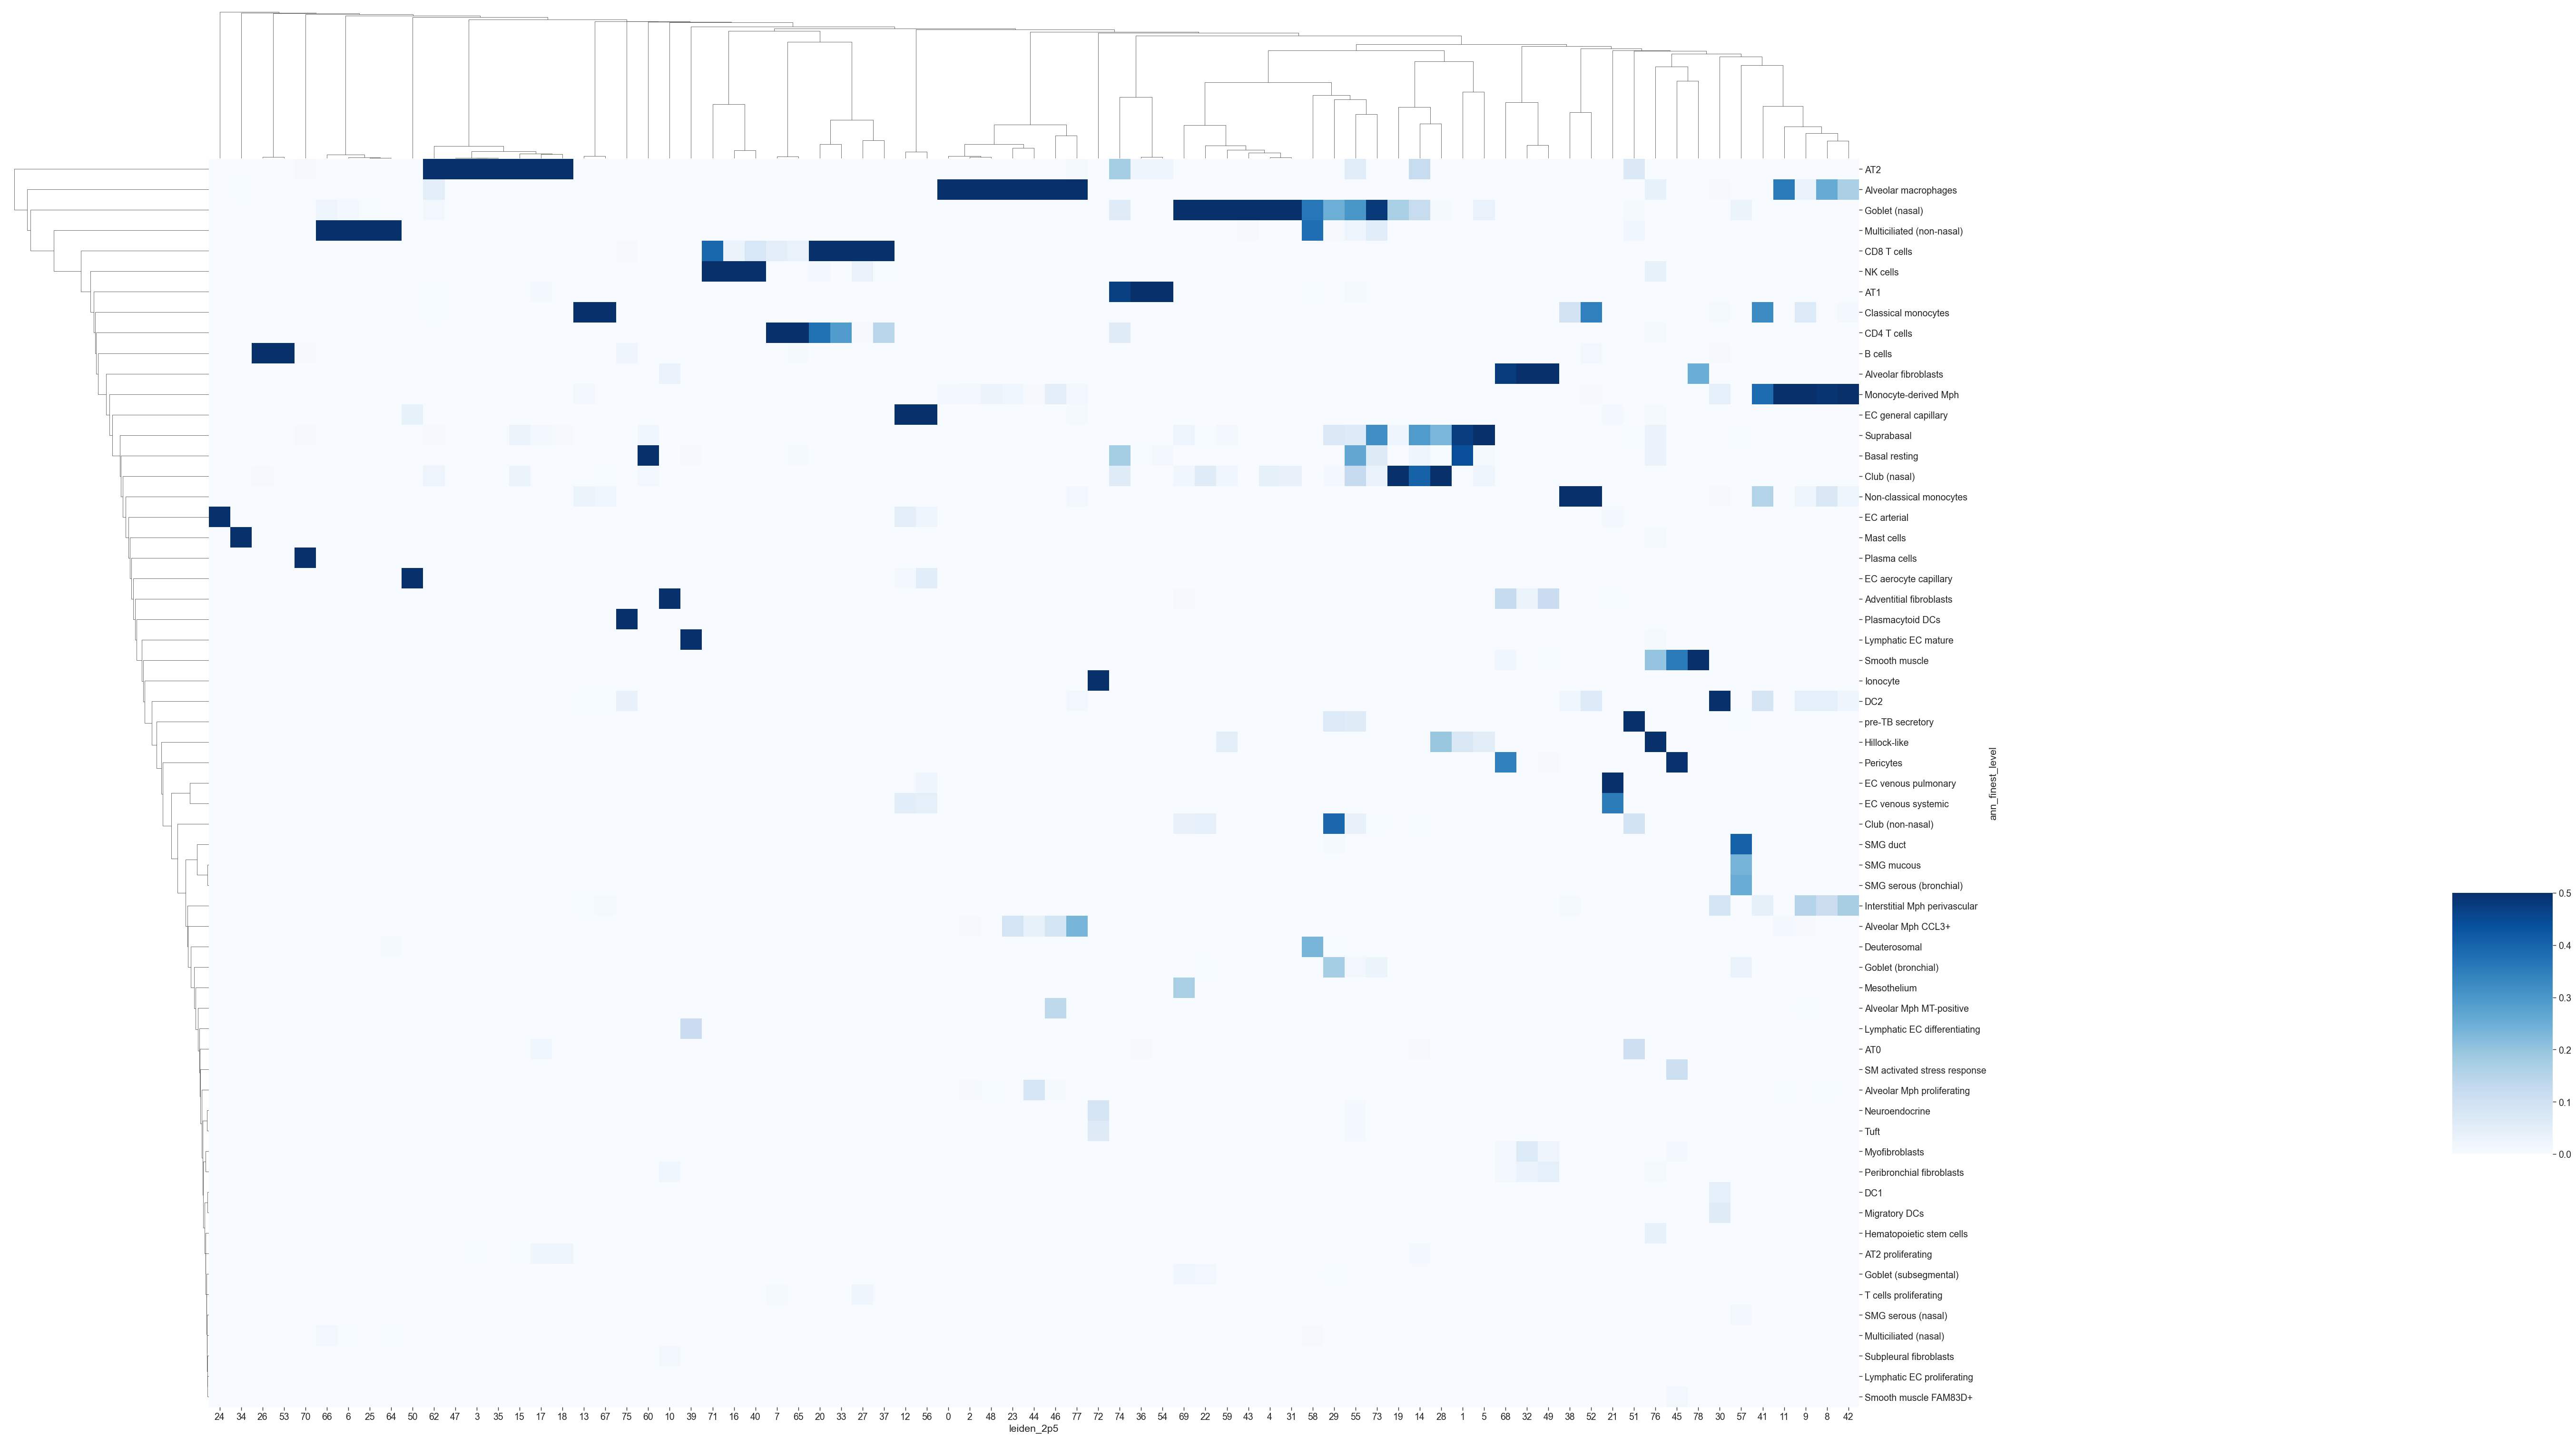

In [15]:
df_vis = atlas_adata.obs.groupby(cluster_col)[assign_ct_col].value_counts(normalize = True).unstack(0)

set_vis_default(font =1.6)
clustermap = sns.clustermap(
    df_vis,
    figsize = (0.55 * df_vis.shape[1], 0.5 * df_vis.shape[0]),
    row_cluster=True, 
    col_cluster=True,
    vmin = 0, vmax = 0.5,
    dendrogram_ratio=0.11,
    cmap = 'Blues',
    cbar_pos=(1.22, 0.2, 0.05, .18)
#     col_colors = col_colors
)
clustermap.ax_heatmap.set_yticklabels(clustermap.ax_heatmap.get_ymajorticklabels(), rotation=0)


# plt.title(lineage)
# plt.ylabel('Actual')
# plt.xlabel('Predicted')
plt.show()
plt.close()


# Raw data (concat all training data, standard preprocess: filter -> normalize & log transform -> hvg)

In [17]:
data_base_path = '/home/share/xwanaf/Img2Expr/data/lung_HLCAbench/pretrain'
data_path = Path(data_base_path)

adata_raw = sc.read(data_path / 'lung_ref_raw_log_scale_hvg.h5ad')

In [ ]:
# adata_raw.write('/import/home2/xwanaf/Img2Expr/data/Benchmarking/reproducibility/lung_ref_raw_log_scale_hvg.h5ad')

In [18]:
adata_raw

AnnData object with n_obs × n_vars = 725801 × 5000
    obs: 'suspension_type', 'donor_id', 'is_primary_data', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', "3'_or_5'", 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'cause_of_death', 'core_or_extension', 'dataset', 'fresh_or_frozen', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3', 'original_ann_level_4', 'original_ann_level_5', 'original_ann_nonharmonized', 'reannotation_type', 'sample', 'scanvi_label', 'sequencing_platform', 'smoking_status', 'study', 'subject_type', 'tissue_coarse_unharmonized', 't

In [19]:
# sc.pp.pca(adata_raw, svd_solver='arpack', n_comps=30, use_highly_variable=False)
# sc.pp.neighbors(adata_raw, metric='cosine', n_neighbors=30, n_pcs = 30)
# sc.tl.umap(adata_raw, min_dist = 0.3, spread = 1, maxiter=100)


/home/xwanaf/.conda/envs/unigenex_env/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


/tmp/ipykernel_420728/3335371162.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(bbox_to_anchor=(1., 1.0))
/tmp/ipykernel_420728/3335371162.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(bbox_to_anchor=(1., 1.0))


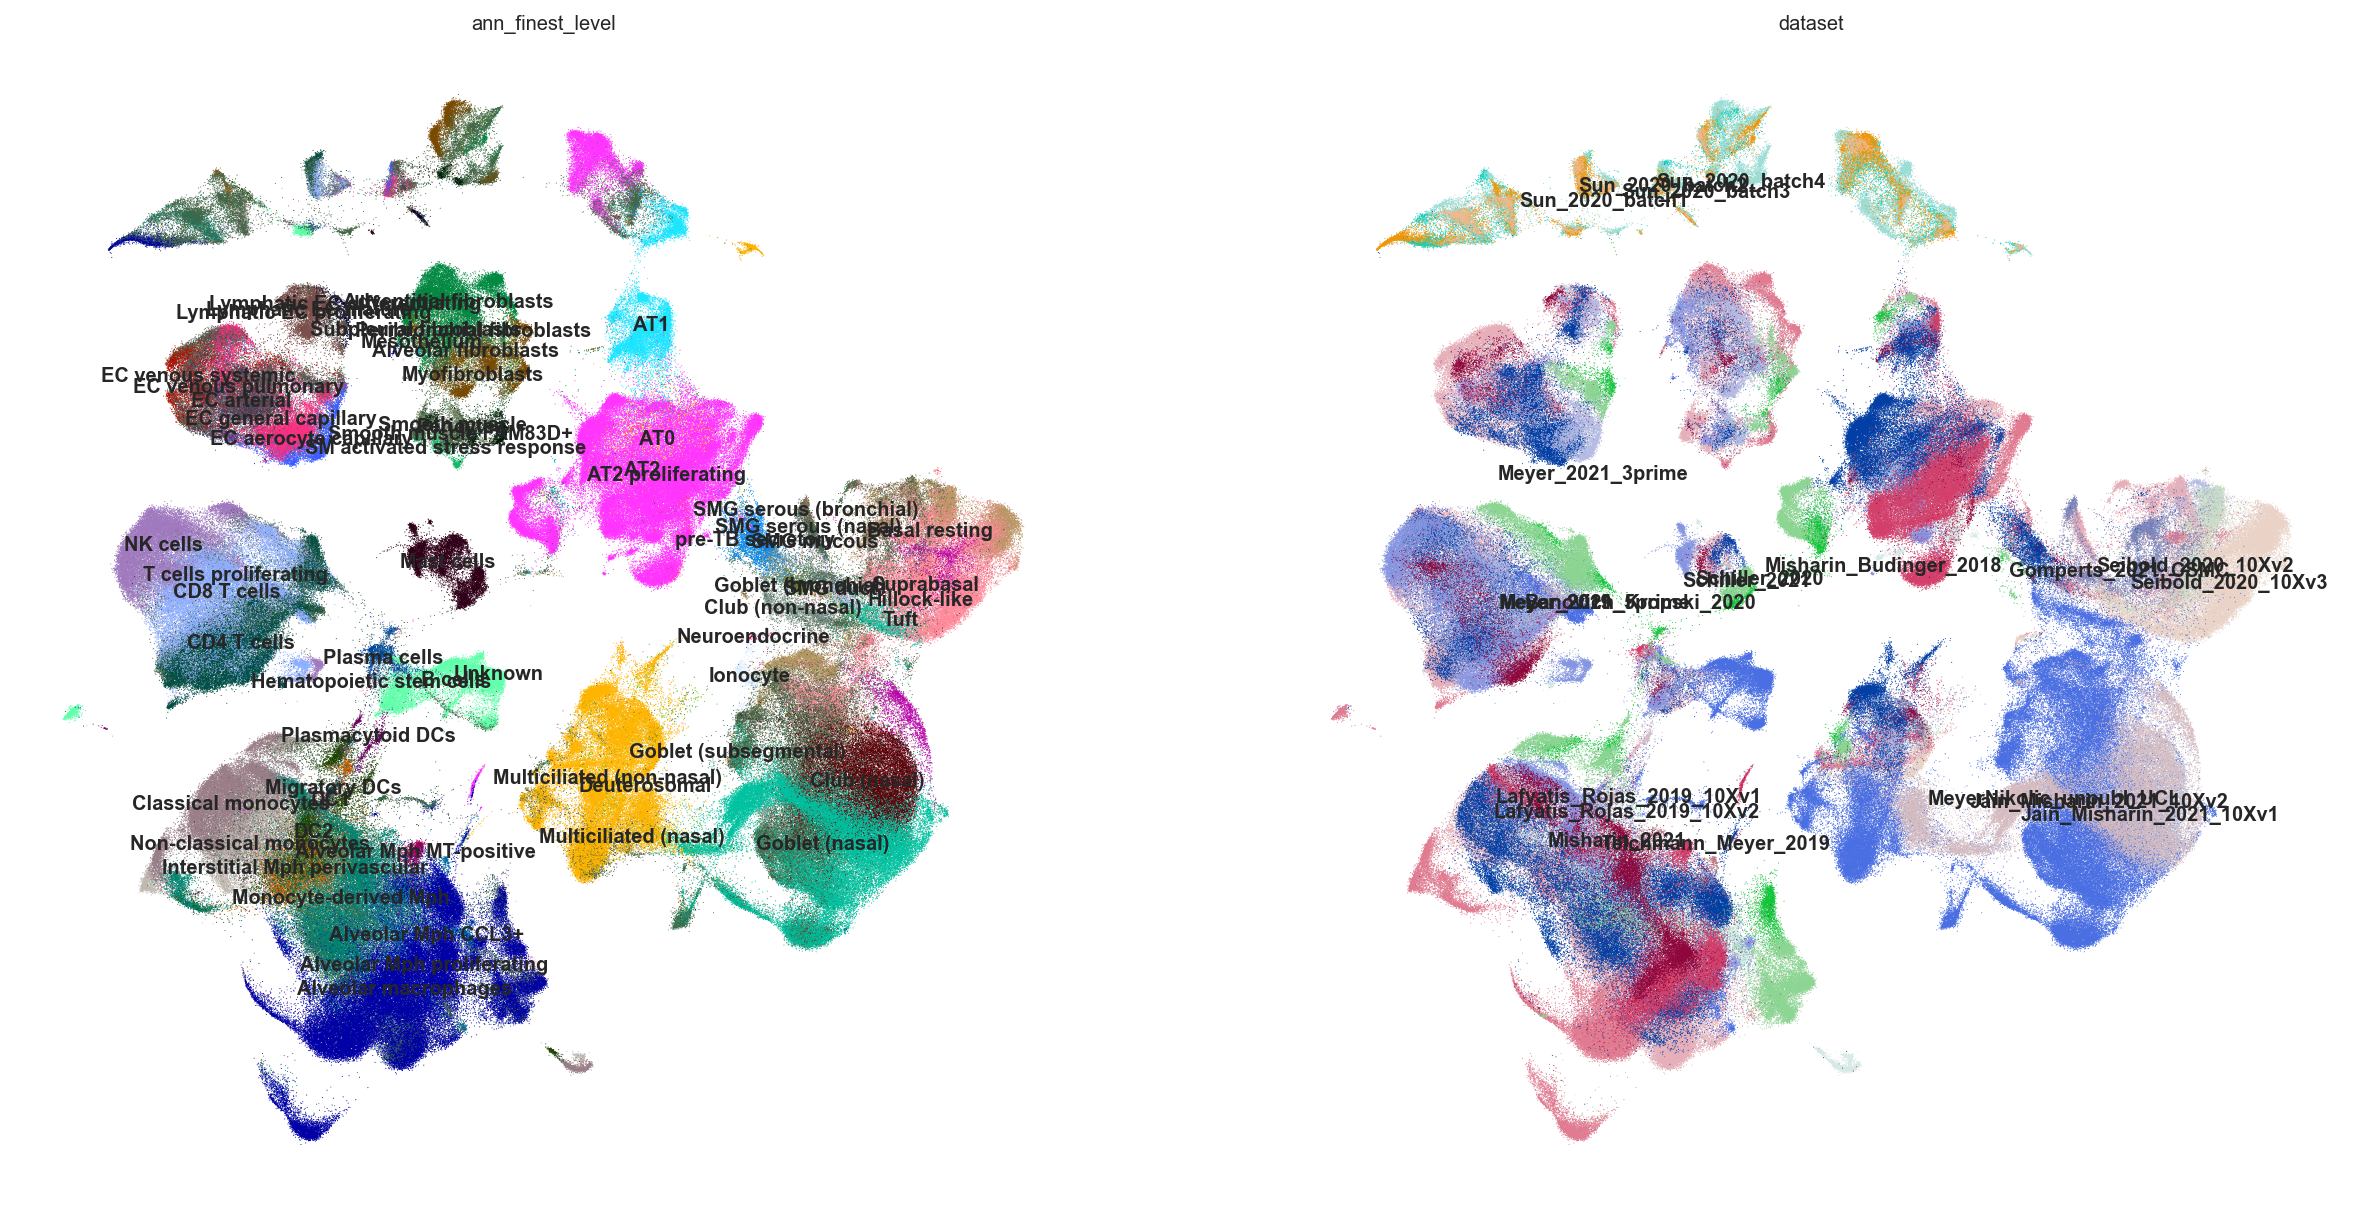

In [21]:
set_vis_default(font = 1., circle_marker = 3.)

adata_vis = adata_raw

fig, axs = plt.subplots(1, 2, figsize=(20, 10), dpi = 150, gridspec_kw={'wspace': .2, 'hspace': 0.05})

sc.pl.umap(
    adata_vis, color='ann_finest_level', 
    size=1, frameon=False, show=False, ax=axs[0], 
#     palette = color_dict, 
#     groups = groups,
    legend_loc = 'on data' 
)
axs[0].legend(bbox_to_anchor=(1., 1.0))


sc.pl.umap(
    adata_vis, color='dataset', 
    size=1, frameon=False, show=False, ax=axs[1], 
#     groups = groups, 
#     palette = color_dict#,
    legend_loc = 'on data' 
)
axs[1].legend(bbox_to_anchor=(1., 1.0))


plt.show()
plt.close()